In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
#Load Dataset

df = pd.read_csv("../data/Nassau Candy Distributor.csv")

#Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
# Number of rows and columns

df.shape

(10194, 18)

In [4]:
#Column Names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [6]:
#Missing Value Check
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [7]:
#Statistical Summary
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [10]:
# Convert date columns correctly (DD-MM-YYYY format)
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

#Check updated datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  str           
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [11]:
# Checking invalid financial records

print("Zero Sales Records:", (df['Sales'] <= 0).sum())

print("Negative Cost Records:", (df['Cost'] < 0).sum())

print("Negative Profit Records:", (df['Gross Profit'] < 0).sum())

Zero Sales Records: 0
Negative Cost Records: 0
Negative Profit Records: 0


In [12]:
# Remove invalid records

df = df[
    (df['Sales'] > 0) &
    (df['Cost'] >= 0)
]
df.shape

(10194, 18)

In [13]:
#KPI'S
# Gross Margin Percentage

df['Gross Margin %'] = (
    df['Gross Profit'] / df['Sales']
) * 100

# Profit Earned Per Product Unit

df['Profit Per Unit'] = (
    df['Gross Profit'] / df['Units']
)

# Revenue Contribution Percentage
df['Revenue Contribution %'] = (
    df['Gross Profit'] / df['Gross Profit'].sum()
) *100

#Profit Contribution Percentage
df['Profit Contribution %'] = (
    df['Gross Profit'] / df['Gross Profit'].sum()
) * 100

#Cost Ratio Percentage

df['Cost Ratio %'] = (
    df['Cost'] / df['Sales']
) * 100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product Name,Sales,Units,Gross Profit,Cost,Gross Margin %,Profit Per Unit,Revenue Contribution %,Profit Contribution %,Cost Ratio %
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11,0.004516,0.004516,35.076923
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45,0.005244,0.005244,34.666667
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49,0.007994,0.007994,28.653295
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50,0.008026,0.008026,30.555556
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,0.007866,0.007866,34.666667


In [14]:
df[
    [
        'Product Name',
        'Sales',
        'Gross Profit',
        'Cost',
        'Gross Margin %',
        'Profit Per Unit'
    ]
].head(10)

,Product Name,Sales,Gross Profit,Cost,Gross Margin %,Profit Per Unit
0,Wonka Bar - Milk Chocolate,6.50,4.22,2.28,64.923077,2.11
1,Wonka Bar - Triple Dazzle Caramel,7.50,4.90,2.60,65.333333,2.45
2,Wonka Bar - Nutty Crunch Surprise,10.47,7.47,3.00,71.346705,2.49
3,Wonka Bar -Scrumdiddlyumptious,10.80,7.50,3.30,69.444444,2.50
4,Wonka Bar - Triple Dazzle Caramel,11.25,7.35,3.90,65.333333,2.45
5,Wonka Bar -Scrumdiddlyumptious,32.40,22.50,9.90,69.444444,2.50
6,Wonka Bar - Triple Dazzle Caramel,7.50,4.90,2.60,65.333333,2.45
7,Wonka Bar - Milk Chocolate,9.75,6.33,3.42,64.923077,2.11
8,Wonka Bar - Nutty Crunch Surprise,6.98,4.98,2.00,71.346705,2.49
9,Wonka Bar - Milk Chocolate,13.00,8.44,4.56,64.923077,2.11


In [16]:
# Top 10 products generating highest profit 

top_profit_products = (
    df.groupby('Product Name')
    ['Gross Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

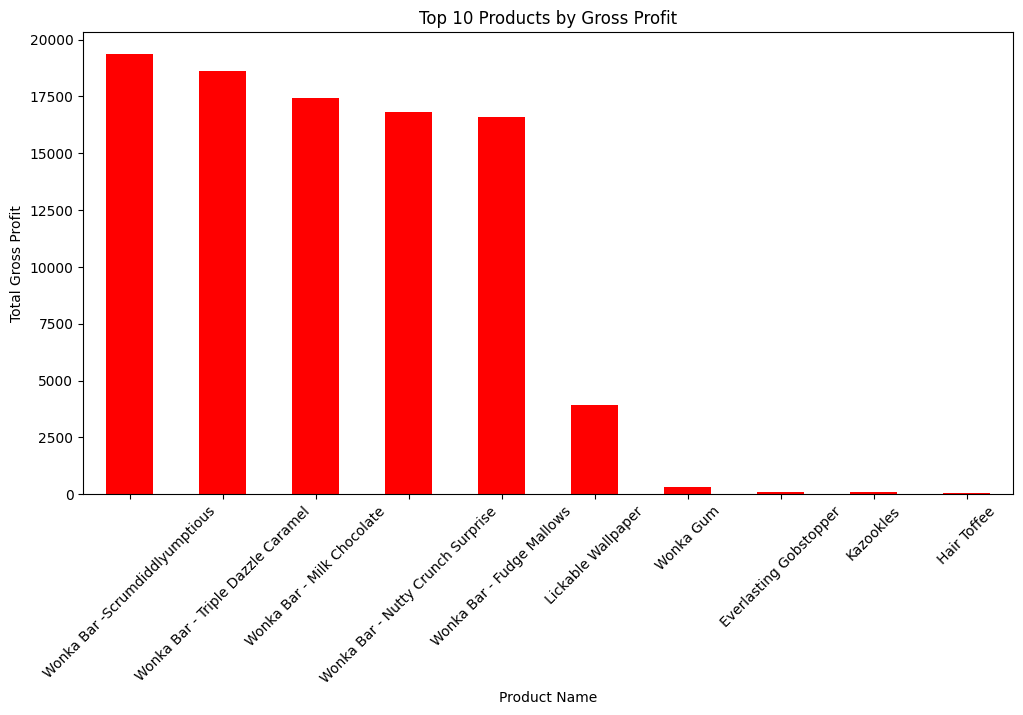

In [21]:
#Top profitable products visualization

plt.figure(figsize=(12,6))

top_profit_products.plot(kind='bar', color ='red')

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Product Name")
plt.ylabel("Total Gross Profit")

plt.xticks(rotation=45)

plt.show()

In [22]:
#Top 10 products by Gross Mrgin %

top_margin_products = (
    df.groupby('Product Name')
    ['Gross Margin %']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_margin_products

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Name: Gross Margin %, dtype: float64

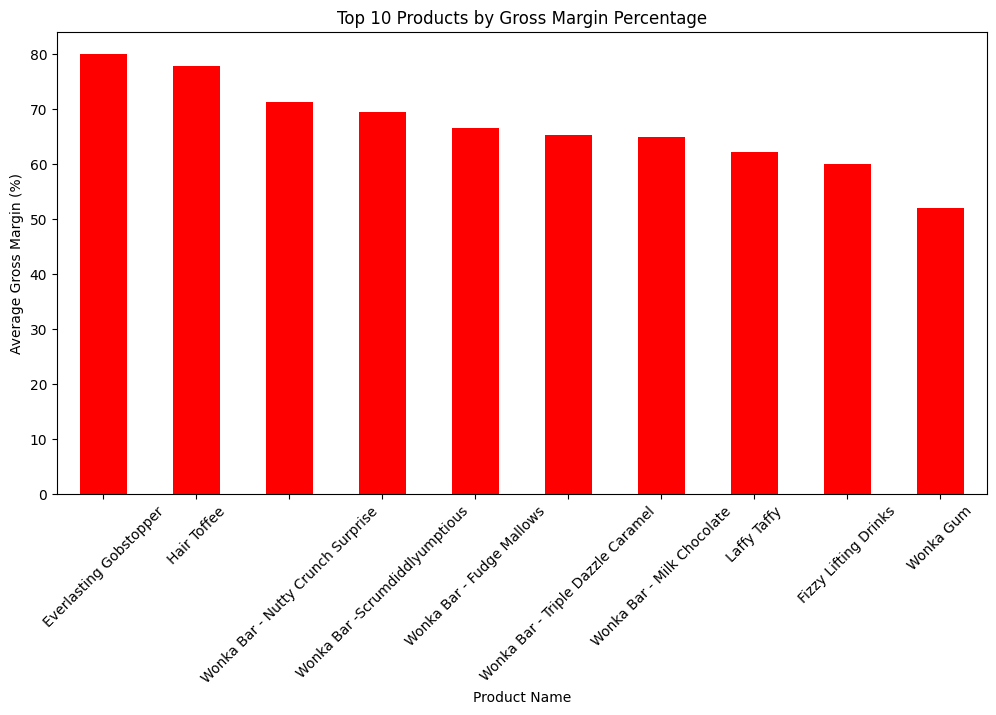

In [23]:
#Visualization of heighest margin products

plt.figure(figsize=(12,6))

top_margin_products.plot(kind = 'bar', color = 'red')

plt.title("Top 10 Products by Gross Margin Percentage")
plt.xlabel("Product Name")
plt.ylabel("Average Gross Margin (%)")

plt.xticks(rotation=45)

plt.show()

In [24]:
# Product Level Analysis

product_analysis = df.groupby(
    'Product Name'
).agg(
    Sales=('Sales', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Gross_Margin=('Gross Margin %', 'mean'),
    Units=('Units', 'sum')
)

product_analysis.head()

,Sales,Gross_Profit,Gross_Margin,Units
Product Name,,,,
Everlasting Gobstopper,130.00,104.00,80.000000,13
Fizzy Lifting Drinks,78.75,47.25,60.000000,21
Fun Dip,12.00,4.80,40.000000,8
Hair Toffee,76.50,59.50,77.777778,17
Kazookles,1205.75,92.75,7.692308,371


In [25]:
# High revenue but low margin products

high_sales_low_margin = product_analysis[
    (product_analysis['Sales'] > product_analysis['Sales'].mean())
    &
    (product_analysis['Gross_Margin'] < product_analysis['Gross_Margin'].mean())
]

high_sales_low_margin

,Sales,Gross_Profit,Gross_Margin,Units
Product Name,,,,


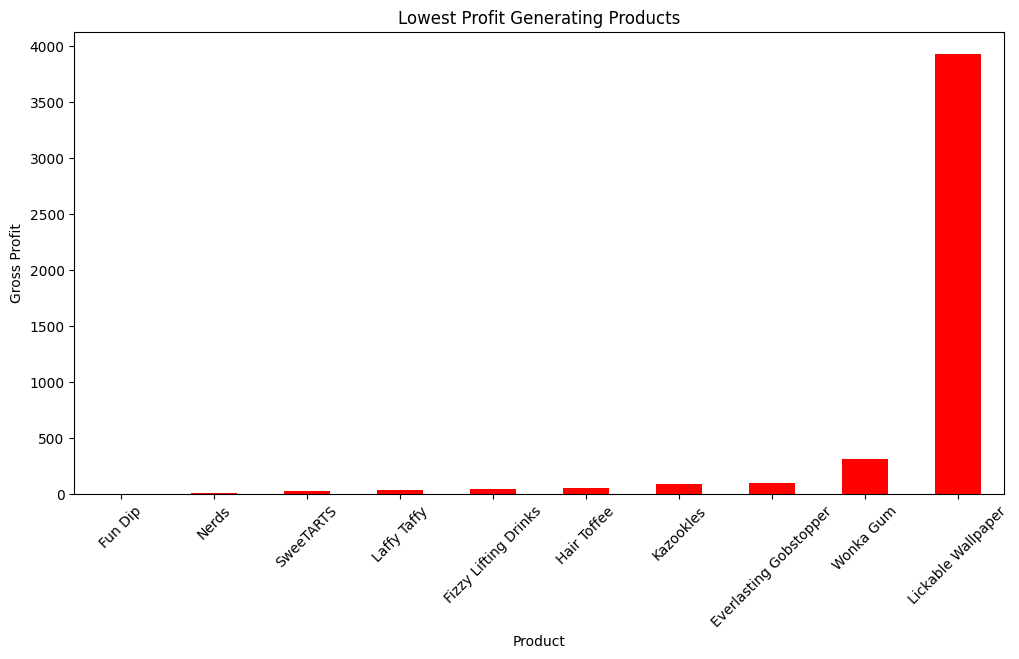

In [26]:
# Bottom Profitable Products

low_profit_products = (
    df.groupby('Product Name')
    ['Gross Profit']
    .sum()
    .sort_values()
    .head(10)
)

low_profit_products

plt.figure(figsize=(12,6))

low_profit_products.plot(kind='bar', color='red')

plt.title("Lowest Profit Generating Products")
plt.xlabel("Product")
plt.ylabel("Gross Profit")

plt.xticks(rotation=45)

plt.show()

In [33]:
df['Gross Margin %'] = (
    df['Gross Profit'] / df['Sales']
)*100

In [34]:
# Division level profitability analysis

division_analysis = df.groupby(
    'Division'
).agg(
    Total_Revenue=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum'),
    Average_Margin=('Gross Margin %', 'mean'),
    Total_Units=('Units', 'sum')
)

division_analysis

,Total_Revenue,Total_Profit,Average_Margin,Total_Units
Division,,,,
Chocolate,131692.90,88824.62,67.458162,37275
Other,9663.25,4333.45,37.672457,1242
Sugar,427.48,284.73,57.689001,137


In [35]:
# Product profit contribution analysis

pareto_profit = (
    df.groupby('Product Name')
    ['Gross Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto_profit.head()

,Product Name,Gross Profit
0,Wonka Bar -Scrumdiddlyumptious,19357.50
1,Wonka Bar - Triple Dazzle Caramel,18610.20
2,Wonka Bar - Milk Chocolate,17443.37
3,Wonka Bar - Nutty Crunch Surprise,16819.95
4,Wonka Bar - Fudge Mallows,16593.60


In [36]:
# Calculate cumulative profit percentage

pareto_profit['Cumulative Profit'] = (
    pareto_profit['Gross Profit'].cumsum()
)

pareto_profit['Cumulative Profit %'] = (
    pareto_profit['Cumulative Profit'] / 
    pareto_profit['Gross Profit'] . sum()
) * 100

pareto_profit.head(10)



,Product Name,Gross Profit,Cumulative Profit,Cumulative Profit %
0,Wonka Bar -Scrumdiddlyumptious,19357.50,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,37967.70,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,55411.07,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,72231.02,77.299717
4,Wonka Bar - Fudge Mallows,16593.60,88824.62,95.057747
5,Lickable Wallpaper,3930.00,92754.62,99.263528
6,Wonka Gum,310.70,93065.32,99.596031
7,Everlasting Gobstopper,104.00,93169.32,99.707329
8,Kazookles,92.75,93262.07,99.806588
9,Hair Toffee,59.50,93321.57,99.870263


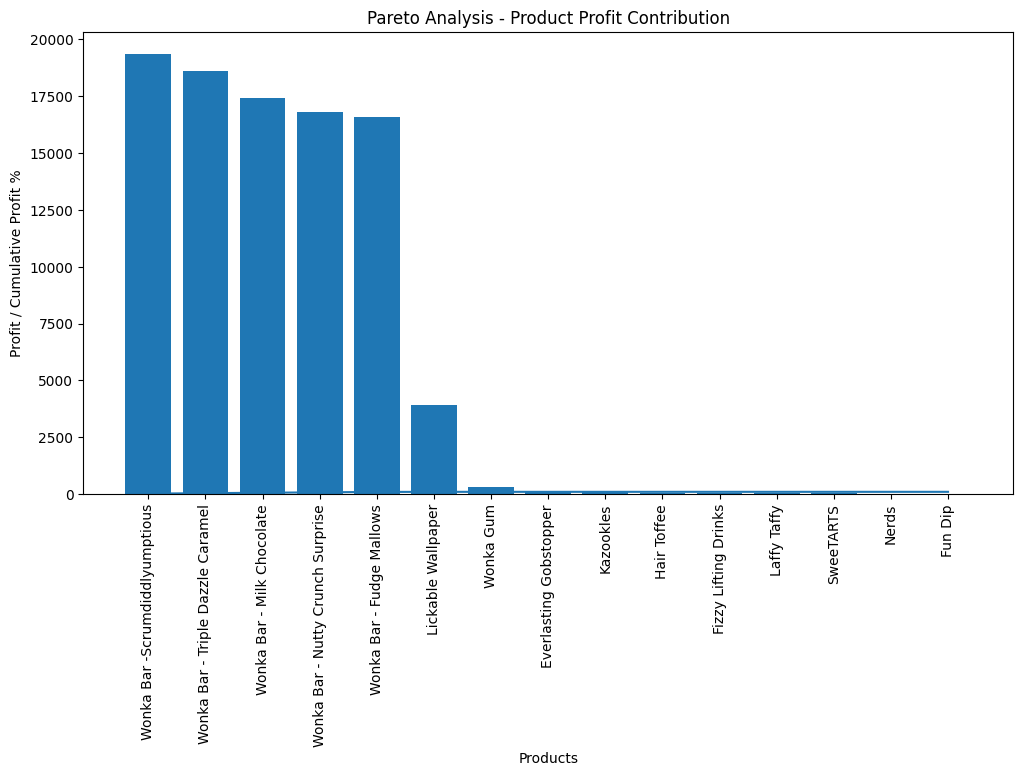

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    pareto_profit['Product Name'],
    pareto_profit['Gross Profit']
)

plt.plot(
    pareto_profit['Product Name'],
    pareto_profit['Cumulative Profit %']
)

plt.title("Pareto Analysis - Product Profit Contribution")

plt.xlabel("Products")
plt.ylabel("Profit / Cumulative Profit %")

plt.xticks(rotation=90)

plt.show()

In [40]:
# Save Final Cleaned Dataset

df.to_csv(
    "../data/Nassau_Candy_Profitability_Cleaned_Data.csv",
    index=False

)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


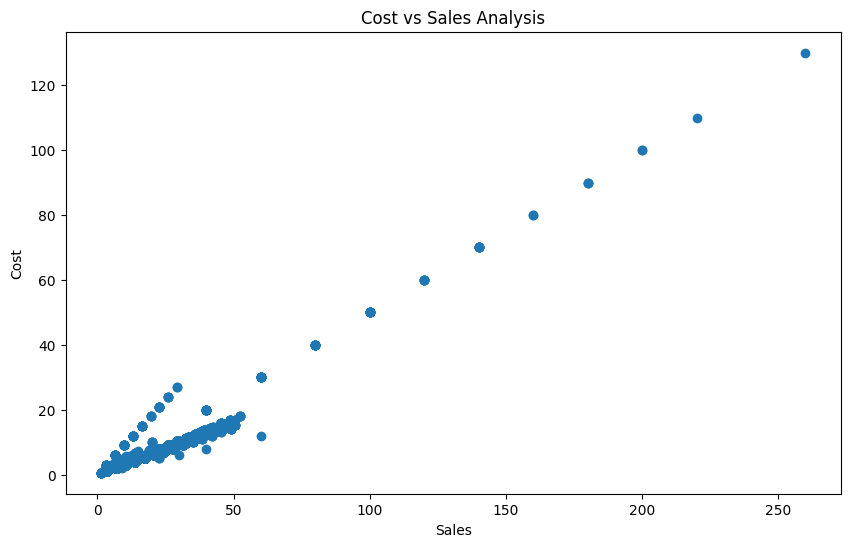

In [41]:
#Cost Vs Sales relationship 

plt.figure(figsize=(10,6))

plt.scatter(
    df['Sales'],
    df['Cost']
)

plt.title("Cost vs Sales Analysis")
plt.xlabel("Sales")
plt.ylabel("Cost")

plt.show()

In [44]:
#Margin Risk Classification

def margin_status(margin):

    if margin >= 50:
        return "High Power Margin"
    elif margin >= 20:
        return "Moderate Power Margin"
    else:
        return "Margin Risk"
df['Margin Status'] = df['Gross Margin %'].apply(margin_status)

df[
[
'Product Name',
'Sales',
'Gross Margin %',
'Margin Status'    
]
].head(20)

,Product Name,Sales,Gross Margin %,Margin Status
0,Wonka Bar - Milk Chocolate,6.50,64.923077,High Power Margin
1,Wonka Bar - Triple Dazzle Caramel,7.50,65.333333,High Power Margin
2,Wonka Bar - Nutty Crunch Surprise,10.47,71.346705,High Power Margin
3,Wonka Bar -Scrumdiddlyumptious,10.80,69.444444,High Power Margin
4,Wonka Bar - Triple Dazzle Caramel,11.25,65.333333,High Power Margin
5,Wonka Bar -Scrumdiddlyumptious,32.40,69.444444,High Power Margin
6,Wonka Bar - Triple Dazzle Caramel,7.50,65.333333,High Power Margin
7,Wonka Bar - Milk Chocolate,9.75,64.923077,High Power Margin
8,Wonka Bar - Nutty Crunch Surprise,6.98,71.346705,High Power Margin
9,Wonka Bar - Milk Chocolate,13.00,64.923077,High Power Margin


In [45]:
#Count product categories

df['Margin Status'].value_counts()

Margin Status
High Power Margin        10081
Margin Risk                 96
Moderate Power Margin       17
Name: count, dtype: int64

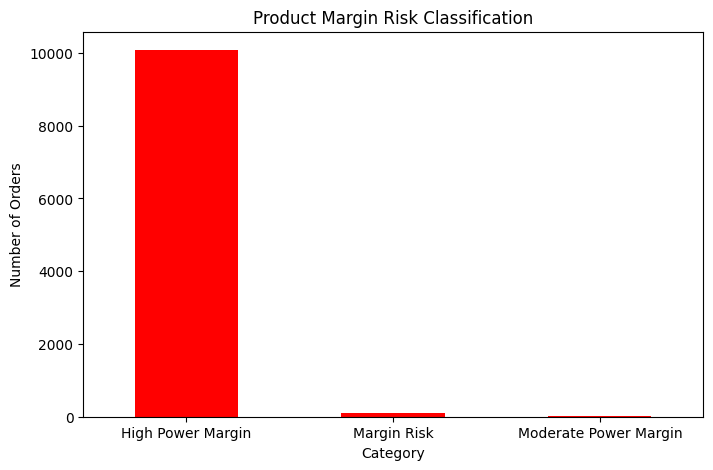

In [46]:
# Margin Risk Visualization
plt.figure(figsize=(8,5))

df['Margin Status'].value_counts().plot(
    kind = 'bar',
    color = 'red'
)
plt.title("Product Margin Risk Classification")

plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.show()

In [48]:
df.to_csv(
    "../data/final_nassau_dashboard_data.csv",
    index=False
)

print("Dashboard Dataset Created Successfully")

Dashboard Dataset Created Successfully
